In [3]:
#%pip install scikit-fda

In [4]:
import pandas as pd
import numpy as np
import zipfile
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import math
import skfda
from skfda.representation.grid import FDataGrid

In [5]:
zip_file_path = 'datos_competicion.zip'
extraction_path = 'data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

'datos_competicion.zip' unzipped to 'data'


In [6]:
trades = pd.read_csv('data/trades_benchmark.csv')

In [7]:
# Convert to datetime (keeps timezone correctly)
trades["timestamp_open"] = pd.to_datetime(trades["dateOpen"], format="mixed")
# Remove timezone
trades["timestamp_open"] = trades["timestamp_open"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_open"] = trades["timestamp_open"].dt.floor("min")


trades["timestamp_close"] = pd.to_datetime(trades["dateClose"], format="mixed")
# Remove timezone
trades["timestamp_close"] = trades["timestamp_close"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_close"] = trades["timestamp_close"].dt.floor("min")


In [8]:
algoritmos_path = r'data/algoritmos'

alg_bench = pd.unique(trades['productname'])
# Get a list of all files in the 'algoritmos' folder
algo_files = [f for f in os.listdir(algoritmos_path) if f.endswith('.csv')]

if algo_files:
    algs_benchmark = [os.path.join(algoritmos_path, name + ".csv") for name in alg_bench]
else:
    print(f"No CSV files found in '{algoritmos_path}'")

In [9]:
horas = set()
fecha_max = datetime(2019,12,31,0,0,0)
fecha_min = datetime(2025,12,31,0,0,0)
for algo in algs_benchmark:

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'], format = "%Y-%m-%d %H:%M:%S")
    horas.update(pd.unique(df['plot_date']))
    fecha_max_algo = df['plot_date'].max()
    fecha_min_algo = df['plot_date'].min()
    if fecha_max_algo > fecha_max:
        fecha_max = fecha_max_algo
    if fecha_min_algo< fecha_min:
        fecha_min = fecha_min_algo
horas = sorted(list(horas))

In [10]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas

In [11]:
import os

for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

In [12]:
df_algoritmos.shape

(7146, 272)

In [13]:
df_algoritmos.head()

,Date,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,...,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
0,2020-06-01 01:00:00,0.0,0.00,0.0,214.49,0.0,207.11,0.0,0.0,133.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-06-01 05:00:00,0.0,189.54,0.0,214.90,0.0,207.17,0.0,0.0,133.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-06-01 09:00:00,0.0,189.55,0.0,214.29,0.0,207.20,0.0,0.0,133.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-06-01 13:00:00,0.0,189.61,0.0,214.21,0.0,207.05,0.0,0.0,133.77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-06-01 17:00:00,0.0,0.00,0.0,214.83,0.0,207.15,0.0,0.0,133.60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
trades['prox_open_hour'] = '-'
trades['prox_close_hour'] = '-'
trades[['precio_open','precio_close']] = 0.0
trades['n_filas'] = 0

for index, row in trades.iterrows():
    fecha_open = row['timestamp_open']
    fecha_close = row['timestamp_close']
    try:
        closest_idx_min = (df_algoritmos["Date"] - fecha_open).abs().idxmin()
        closest_idx_max = (df_algoritmos["Date"] - fecha_close).abs().idxmin()
        n_filas = closest_idx_max - closest_idx_min + 1
    except:
        pass
    trades.loc[index, 'prox_open_hour']= df_algoritmos.loc[closest_idx_min,'Date']
    trades.loc[index, 'prox_close_hour']= df_algoritmos.loc[closest_idx_max,'Date']
    trades.loc[index,'n_filas'] = n_filas
    trades.loc[index,'precio_open'] = df_algoritmos.loc[closest_idx_min,row['productname']]
    trades.loc[index,'precio_close'] = df_algoritmos.loc[closest_idx_max,row['productname']]
trades['profit_percentage'] = trades.apply(lambda row:  (row['precio_close'] - row['precio_open'])/row['precio_open']
                                            if (row['precio_open']!=0 and row['precio_close']!=0) else 0, axis = 1)
trades['trade_length'] = (trades['timestamp_close'] - trades['timestamp_open'])/np.timedelta64(1,'D')

In [15]:
trades_finalizados = trades.loc[trades['n_filas']!=0]

In [16]:
#para hacer una evaluación del comportamiento, es importante tener unos cuantos puntos para graficar el comportamiento
#en particular, necesitamos los datos del algoritmo correspondiente para el momento de cierre. 
df_completo = trades_finalizados.loc[(pd.to_datetime(trades_finalizados['prox_close_hour']).dt.day == pd.to_datetime(trades_finalizados['timestamp_close']).dt.day)
    & trades_finalizados['profit_percentage']!=0, ['productname','prox_open_hour','prox_close_hour', 'n_filas','precio_open','precio_close','profit_percentage','trade_length']]
df_completo.reset_index(inplace=True,drop=True)

In [17]:
#necesitamos una función que normalice funciones con una gaussiana a un dominio común del intervalo [0,1]
def gaussian_kernel_smoother(x, y, x_eval, bandwidth):
    x = np.asarray(x).flatten()
    y = np.asarray(y).flatten()
    x_eval = np.asarray(x_eval).flatten()

    # Compute squared distance matrix
    diff = x_eval[:, None] - x[None, :]

    # Gaussian kernel weights
    weights = np.exp(-0.5 * (diff / bandwidth)**2)

    # Normalize weights
    weights /= np.sum(weights, axis=1, keepdims=True)

    # Smoothed values
    y_smooth = weights @ y
    return y_smooth


In [18]:
df_completo

,productname,prox_open_hour,prox_close_hour,n_filas,precio_open,precio_close,profit_percentage,trade_length
0,EFKyf,2020-06-03 17:00:00,2020-07-08 09:00:00,149,215.44,222.51,0.032817,34.725694
1,lVhDF,2020-06-03 17:00:00,2020-12-23 06:00:00,868,157.19,144.18,-0.082766,202.574306
2,RsCCj,2020-06-03 17:00:00,2020-07-23 17:00:00,217,207.65,188.86,-0.090489,49.934722
3,yqSyy,2020-06-04 17:00:00,2021-03-05 18:00:00,1165,201.27,210.92,0.047946,274.112500
4,MeTxk,2020-06-11 21:00:00,2020-07-29 13:00:00,203,134.00,136.23,0.016642,47.548611
...,...,...,...,...,...,...,...,...
2540,AmsD8,2024-12-19 14:00:00,2024-12-20 14:00:00,7,148.50,148.61,0.000741,0.999306
2541,UCc87,2024-12-19 14:00:00,2024-12-20 14:00:00,7,86.50,86.35,-0.001734,0.999306
2542,AmsD8,2024-12-24 14:00:00,2024-12-30 14:00:00,19,149.32,149.14,-0.001205,5.999306
2543,2Zc0n,2024-12-24 14:00:00,2024-12-26 14:00:00,7,129.45,129.27,-0.001390,1.999306


In [19]:
trades_coarse_functions = []
for index, row in df_completo.iterrows():
    precios = [df_algoritmos.loc[(df_algoritmos['Date']>=row['prox_open_hour']) & (df_algoritmos['Date']<=row['prox_close_hour']),row['productname']].values]
    trades_coarse_functions.append([index, np.linspace(0,1,row['n_filas']),np.array(precios)/np.array(precios).mean()])

In [20]:
x_common = np.linspace(0,1,200)
smooth_functions = []
bandwidth = 0.04
for index_i,x_i,y_i in trades_coarse_functions:
    smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


## Cuándo vender

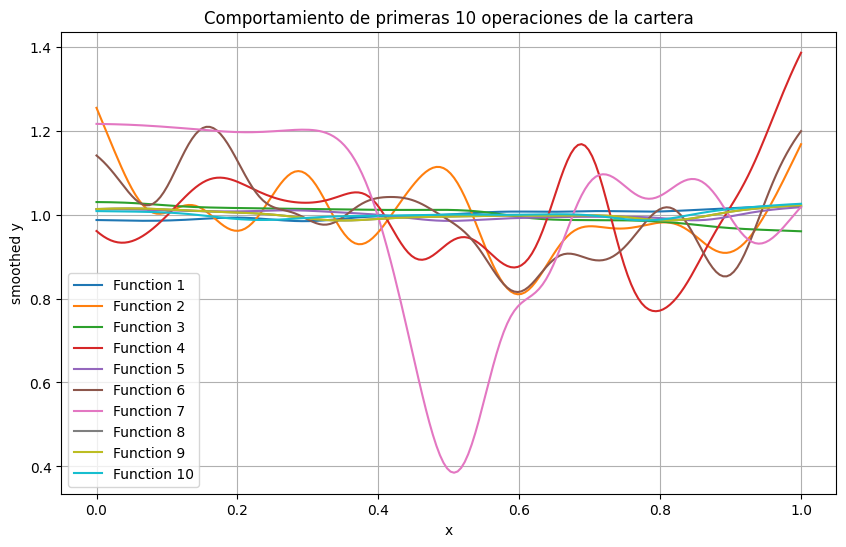

In [21]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()

Tenemos que ver si es posible clasificar el comportamiento de los productos antes de que se adquirieran por la cartera (razones para comprar)

In [22]:
trades_history_coarse_functions = []
for index, row in df_completo.iterrows():
    precios_previos = df_algoritmos.loc[(df_algoritmos['Date']<=row['prox_open_hour']) & (df_algoritmos[row['productname']]!=0),row['productname']].values
    trades_history_coarse_functions.append([index, np.linspace(0,1,len(precios_previos[:35])),np.array(precios_previos[:35])/np.array(precios_previos[:35]).mean()])

In [23]:
history_smooth_functions = []
x_common = np.linspace(0,1,200)
andwidth = 0.04
for index_i,x_i,y_i in trades_history_coarse_functions:
    history_smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


## Cuándo comprar

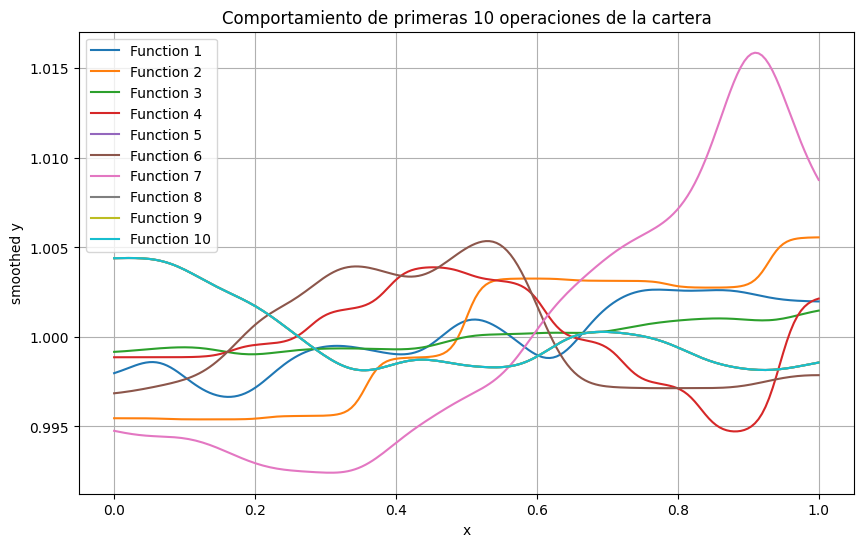

In [24]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, history_smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
%pip install deap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: C:\Users\anruk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## TRADES

In [26]:
df_completo

,productname,prox_open_hour,prox_close_hour,n_filas,precio_open,precio_close,profit_percentage,trade_length
0,EFKyf,2020-06-03 17:00:00,2020-07-08 09:00:00,149,215.44,222.51,0.032817,34.725694
1,lVhDF,2020-06-03 17:00:00,2020-12-23 06:00:00,868,157.19,144.18,-0.082766,202.574306
2,RsCCj,2020-06-03 17:00:00,2020-07-23 17:00:00,217,207.65,188.86,-0.090489,49.934722
3,yqSyy,2020-06-04 17:00:00,2021-03-05 18:00:00,1165,201.27,210.92,0.047946,274.112500
4,MeTxk,2020-06-11 21:00:00,2020-07-29 13:00:00,203,134.00,136.23,0.016642,47.548611
...,...,...,...,...,...,...,...,...
2540,AmsD8,2024-12-19 14:00:00,2024-12-20 14:00:00,7,148.50,148.61,0.000741,0.999306
2541,UCc87,2024-12-19 14:00:00,2024-12-20 14:00:00,7,86.50,86.35,-0.001734,0.999306
2542,AmsD8,2024-12-24 14:00:00,2024-12-30 14:00:00,19,149.32,149.14,-0.001205,5.999306
2543,2Zc0n,2024-12-24 14:00:00,2024-12-26 14:00:00,7,129.45,129.27,-0.001390,1.999306


## DF Algoritmos

In [27]:
df_algoritmos

,Date,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,...,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
0,2020-06-01 01:00:00,0.00,0.00,0.0,214.49,0.00,207.11,0.00,0.0,133.75,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
1,2020-06-01 05:00:00,0.00,189.54,0.0,214.90,0.00,207.17,0.00,0.0,133.75,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
2,2020-06-01 09:00:00,0.00,189.55,0.0,214.29,0.00,207.20,0.00,0.0,133.79,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
3,2020-06-01 13:00:00,0.00,189.61,0.0,214.21,0.00,207.05,0.00,0.0,133.77,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
4,2020-06-01 17:00:00,0.00,0.00,0.0,214.83,0.00,207.15,0.00,0.0,133.60,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7141,2024-12-30 06:00:00,0.00,0.00,0.0,323.75,0.00,0.00,0.00,0.0,0.00,...,135.27,0.00,129.85,0.00,0.00,0.0,120.78,120.90,130.78,149.14
7142,2024-12-30 10:00:00,0.00,0.00,0.0,323.85,0.00,0.00,0.00,0.0,0.00,...,135.25,0.00,129.86,0.00,0.00,0.0,121.06,120.93,130.70,149.14
7143,2024-12-30 14:00:00,0.00,0.00,0.0,325.84,0.00,0.00,0.00,0.0,0.00,...,135.35,0.00,129.88,0.00,0.00,0.0,120.86,120.76,129.50,149.14
7144,2024-12-30 18:00:00,70.88,0.00,0.0,324.54,151.71,0.00,921.85,0.0,0.00,...,135.60,124.61,130.20,136.09,213.22,0.0,121.11,120.88,130.64,148.48


In [28]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas
for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

### Opción 1

In [29]:
# df_algoritmos ya debe estar cargado
# Aseguramos que 0 se interprete como "sin dato"
df_prices = df_algoritmos.set_index("Date").replace(0, np.nan)
df_prices.head(2)

,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,lVdo5,...,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01 01:00:00,NaN,NaN,NaN,214.49,NaN,207.11,NaN,NaN,133.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-01 05:00:00,NaN,189.54,NaN,214.90,NaN,207.17,NaN,NaN,133.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Fechas del histórico
fechas = df_prices.index
fechas

DatetimeIndex(['2020-06-01 01:00:00', '2020-06-01 05:00:00',
               '2020-06-01 09:00:00', '2020-06-01 13:00:00',
               '2020-06-01 17:00:00', '2020-06-01 21:00:00',
               '2020-06-02 01:00:00', '2020-06-02 05:00:00',
               '2020-06-02 09:00:00', '2020-06-02 13:00:00',
               ...
               '2024-12-27 10:00:00', '2024-12-27 14:00:00',
               '2024-12-27 18:00:00', '2024-12-29 22:00:00',
               '2024-12-30 02:00:00', '2024-12-30 06:00:00',
               '2024-12-30 10:00:00', '2024-12-30 14:00:00',
               '2024-12-30 18:00:00', '2024-12-30 22:00:00'],
              dtype='datetime64[ns]', name='Date', length=7146, freq=None)

In [31]:
fechas[0]

Timestamp('2020-06-01 01:00:00')

In [32]:
df_disponible = df_prices.loc[:fechas[3]].dropna(axis=1, how='all')
df_disponible

,HcI9f,EFKyf,RsCCj,MeTxk,Mvijr,kFLwG,ynUj1,gN1qP,ke3ev,4Ddpm,...,OYSiN,hOJYz,wYejb,DbojW,u9rnm,UCc87,RNLWE,MGBgz,RJJ1f,5TuAI
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01 01:00:00,NaN,214.49,207.11,133.75,NaN,NaN,NaN,191.14,NaN,130.60,...,NaN,97.86,130.84,119.30,119.93,73.56,92.46,91.08,78.11,112.88
2020-06-01 05:00:00,189.54,214.90,207.17,133.75,NaN,156.25,NaN,190.88,NaN,130.32,...,106.84,97.82,131.11,118.76,121.13,73.18,92.53,91.09,78.16,112.87
2020-06-01 09:00:00,189.55,214.29,207.20,133.79,163.89,156.61,556.93,190.76,NaN,130.50,...,106.58,98.03,131.24,118.11,120.37,NaN,92.45,91.18,77.98,NaN
2020-06-01 13:00:00,189.61,214.21,207.05,133.77,163.59,156.54,557.29,191.40,145.6,129.93,...,NaN,98.08,130.61,117.58,120.57,73.72,92.50,91.28,78.20,NaN


In [33]:
activos = df_prices.columns
activos

Index(['fpJbh', 'HcI9f', 'QEwOm', 'EFKyf', 'lVhDF', 'RsCCj', 'LYP1Q', 'yqSyy',
       'MeTxk', 'lVdo5',
       ...
       'INaLS', 'V7Lrn', 'KLCQs', 'eLk6n', 'IfdDD', 'uPX0V', 'fS7OL', 'bpN6K',
       'eACAc', 'AmsD8'],
      dtype='object', length=271)

In [34]:
activos = df_disponible.columns
activos

Index(['HcI9f', 'EFKyf', 'RsCCj', 'MeTxk', 'Mvijr', 'kFLwG', 'ynUj1', 'gN1qP',
       'ke3ev', '4Ddpm', 'Ev5zR', '3CQHn', 'kjfaW', '9FVCS', 'EBOiR', 'emnH5',
       '7uQma', 'tLGwY', 'UQILX', 'iCWTz', 'G1SiC', 'LcO0Z', 'Ak3Ey', 'WHhrm',
       'Zouwi', 'reFvD', 'RG1b0', 'kjIh4', 'o55dk', 'IWj4m', '7Gz2L', 'c0dJa',
       'u9WP3', '8o49M', 'WW7Po', 'zyWXO', 'ihRDA', 'OYSiN', 'hOJYz', 'wYejb',
       'DbojW', 'u9rnm', 'UCc87', 'RNLWE', 'MGBgz', 'RJJ1f', '5TuAI'],
      dtype='object')

In [35]:
import numpy as np
import pandas as pd

# -----------------------------
# Parámetros
# -----------------------------
Q = 0.5           # factor de riesgo
MAX_ACTIVOS = 5   # máximo 5 activos por fecha
VENTANA = 20      # ventana rolling para calcular retornos
EPSILON = 1e-8    # evita división por cero

# df_algoritmos ya debe estar cargado
# Aseguramos que 0 se interprete como "sin dato"
df_prices = df_algoritmos.set_index("Date").replace(0, np.nan)

# Diccionario para guardar resultados
carteras = {}

# Fechas del histórico
fechas = df_prices.index

# -----------------------------
# Loop sobre fechas
# -----------------------------
for fecha in fechas:
    # Activos disponibles hasta esta fecha
    
    df_disponible = df_prices.loc[:fecha].dropna(axis=1, how='all')
    
    activos = df_disponible.columns
    n = len(activos)
    
    if n == 0:
        carteras[fecha] = []
        continue

    # Calculamos retornos de la ventana más reciente
    returns = df_disponible[activos].pct_change(fill_method=None).dropna(how='all')
    returns = returns.tail(VENTANA)

    # Evitar warnings si hay muy pocos datos
    if returns.shape[0] < 2:
        carteras[fecha] = []
        continue

    # Retornos esperados y matriz de covarianza
    mu = returns.mean(skipna=True).values
    cov = returns.cov().values

    # Evitar covariancias con NaN
    cov = np.nan_to_num(cov, nan=0.0)

    # Riesgo individual (diagonal)
    riesgo_ind = np.diag(cov)

    # Score para selección: mu - Q*riesgo
    score = mu - Q * riesgo_ind

    # Evitar división por cero si usaras mu/risgo_ind
    # score = mu / (riesgo_ind + EPSILON)

    # Orden descendente
    indices_orden = np.argsort(score)[::-1]

    # Seleccionamos hasta MAX_ACTIVOS
    seleccionados = [activos[i] for i in indices_orden[:min(MAX_ACTIVOS, n)]]

    carteras[fecha] = seleccionados

# Convertimos a DataFrame
df_carteras = pd.DataFrame(list(carteras.items()), columns=['Date', 'Activos'])

# Mostrar primeras 20 fechas
print(df_carteras.head(20))


                  Date                              Activos
0  2020-06-01 01:00:00                                   []
1  2020-06-01 05:00:00                                   []
2  2020-06-01 09:00:00  [Mvijr, ynUj1, Zouwi, Ev5zR, kjfaW]
3  2020-06-01 13:00:00  [Zouwi, ke3ev, c0dJa, IWj4m, G1SiC]
4  2020-06-01 17:00:00  [IZexz, Zouwi, G1SiC, pb2zU, rKjYg]
5  2020-06-01 21:00:00  [IfdDD, yFp3w, lVdo5, 0m0In, pos3v]
6  2020-06-02 01:00:00  [IfdDD, yqSyy, 0m0In, lVdo5, pos3v]
7  2020-06-02 05:00:00  [IfdDD, yFp3w, aX1A3, pos3v, 1uL6a]
8  2020-06-02 09:00:00  [IfdDD, yFp3w, aX1A3, pos3v, wSG9M]
9  2020-06-02 13:00:00  [IfdDD, aX1A3, wSG9M, 2EnQY, KMbKa]
10 2020-06-02 17:00:00  [IfdDD, yFp3w, aX1A3, wSG9M, 2EnQY]
11 2020-06-02 21:00:00  [IfdDD, yFp3w, 2EnQY, 9YYu5, WP8P8]
12 2020-06-03 01:00:00  [IfdDD, yFp3w, H0r8b, Mt0w3, 2EnQY]
13 2020-06-03 05:00:00  [IfdDD, q4aE1, nibNX, yFp3w, H0r8b]
14 2020-06-03 09:00:00  [IfdDD, H0r8b, yFp3w, Mt0w3, 2EnQY]
15 2020-06-03 13:00:00  [IfdDD, H0r8b, y

In [36]:
df_carteras.tail()

,Date,Activos
7141,2024-12-30 06:00:00,"[3CQHn, ftSR7, sE0hK, q4aE1, Mvijr]"
7142,2024-12-30 10:00:00,"[3CQHn, vDodF, q4aE1, GkFcy, ftSR7]"
7143,2024-12-30 14:00:00,"[3CQHn, vDodF, ftSR7, sE0hK, 61tRv]"
7144,2024-12-30 18:00:00,"[Mvijr, 3CQHn, q4aE1, GkFcy, CkEpy]"
7145,2024-12-30 22:00:00,"[q4aE1, sE0hK, GkFcy, Mvijr, CkEpy]"


In [37]:
len(mu)

271

### Opción 1.2

In [38]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas
for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

In [39]:
import pandas as pd
import numpy as np
from itertools import combinations


In [40]:
import numpy as np
import pandas as pd

# -----------------------------
# Parámetros
# -----------------------------
Q = 0.5
MAX_ACTIVOS = 5
VENTANA = 20

# -----------------------------
# Datos
# -----------------------------
# 0 = sin dato → NaN
df_prices = df_algoritmos.set_index("Date").replace(0, np.nan)
fechas = df_prices.index

# -----------------------------
# Estructuras
# -----------------------------
carteras = {}            # activos seleccionados
capital_por_activo = {}  # {activo: capital}
valor_total = {}         # capital total
pesos_debug = {}         # lista de capitales por activo (debug)

capital_total = 1.0      # empezamos con 100%

# -----------------------------
# Loop principal
# -----------------------------
for i in range(len(fechas) - 1):
    fecha = fechas[i]
    fecha_sig = fechas[i + 1]

    # Inicializar estructuras
    carteras[fecha] = []
    pesos_debug[fecha] = []

    # -----------------------------
    # Selección de activos
    # -----------------------------
    df_disponible = df_prices.loc[:fecha].dropna(axis=1, how="all")
    activos = df_disponible.columns
    n = len(activos)

    if n == 0:
        continue

    returns = df_disponible[activos].pct_change(fill_method=None).dropna(how="all")
    returns = returns.tail(VENTANA)

    if returns.shape[0] < 2:
        continue

    mu = returns.mean(skipna=True).values
    cov = np.nan_to_num(returns.cov().values, nan=0.0)
    riesgo = np.diag(cov)

    score = mu - Q * riesgo
    indices = np.argsort(score)[::-1]
    seleccionados = [activos[i] for i in indices[:min(MAX_ACTIVOS, n)]]

    carteras[fecha] = seleccionados

    # -----------------------------
    # Primera inversión (20% cada uno)
    # -----------------------------
    if not capital_por_activo and seleccionados:
        peso = capital_total / len(seleccionados)
        capital_por_activo = {a: peso for a in seleccionados}
        valor_total[fecha] = capital_total
        pesos_debug[fecha] = [peso] * len(seleccionados)
        continue

    # -----------------------------
    # Actualizar capital de activos que continúan
    # -----------------------------
    nuevos_capitales = {}

    for activo, cap in capital_por_activo.items():
        if activo in seleccionados:
            p0 = df_prices.loc[fecha, activo]
            p1 = df_prices.loc[fecha_sig, activo]

            # si no hay precio → mantener capital
            if pd.isna(p0) or pd.isna(p1):
                nuevos_capitales[activo] = cap
            else:
                nuevos_capitales[activo] = cap * (p1 / p0)

    # -----------------------------
    # Capital liberado por ventas
    # -----------------------------
    capital_libre = capital_total - sum(nuevos_capitales.values())

    # -----------------------------
    # Comprar activos nuevos (heredan capital)
    # -----------------------------
    nuevos = [a for a in seleccionados if a not in nuevos_capitales]

    if nuevos:
        reparto = capital_libre / len(nuevos)
        for a in nuevos:
            nuevos_capitales[a] = reparto

    # -----------------------------
    # Actualizar estado
    # -----------------------------
    capital_por_activo = nuevos_capitales
    capital_total = sum(capital_por_activo.values())

    # 🔑 Guardamos capital en la fecha siguiente, y pesos alineados con la cartera seleccionada
    valor_total[fecha_sig] = capital_total
    pesos_debug[fecha_sig] = [capital_por_activo.get(a, 0) for a in seleccionados]

# -----------------------------
# DataFrame final
# -----------------------------
df_carteras = pd.DataFrame({
    "Date": list(valor_total.keys()),
    "Activos": [carteras.get(f, []) for f in valor_total.keys()],
    "% Invertido": [valor_total[f] for f in valor_total.keys()],
    "% por Activo": [pesos_debug.get(f, []) for f in valor_total.keys()]
})

df_carteras["Retorno"] = df_carteras["% Invertido"].pct_change().fillna(0)

print(df_carteras.head(20))


KeyboardInterrupt: 

In [ ]:
df_carteras.tail(15)

,Date,Activos,% Invertido,% por Activo,Retorno
7128,2024-12-26 14:00:00,"[Mvijr, vDodF, 6K07g, CkEpy, GkFcy]",0.957645,[],0.0
7129,2024-12-26 18:00:00,"[vDodF, 61tRv, CkEpy, GkFcy, q4aE1]",0.957645,[],0.0
7130,2024-12-26 22:00:00,"[CkEpy, ftSR7, Mvijr, 61tRv, 6K07g]",0.957645,[],0.0
7131,2024-12-27 02:00:00,"[GkFcy, q4aE1, 3CQHn, ftSR7, sE0hK]",0.957645,[],0.0
7132,2024-12-27 06:00:00,"[kfqHw, aX1A3, UQILX, rKjYg, uPX0V]",0.957645,[],0.0
7133,2024-12-27 10:00:00,"[6K07g, k5ecp, KMbKa, MkRxS, uPX0V]",0.957645,[],0.0
7134,2024-12-27 14:00:00,"[UQILX, aX1A3, 5r1Rh, KMbKa, uPX0V]",0.957645,[],0.0
7135,2024-12-27 18:00:00,"[u9WP3, WTetH, 63EZx, 6BB3r, uPX0V]",0.957645,[],0.0
7136,2024-12-29 22:00:00,"[vDodF, ftSR7, Mvijr, 61tRv, 3CQHn]",0.957645,[],0.0
7137,2024-12-30 02:00:00,"[3CQHn, ftSR7, sE0hK, 61tRv, Mvijr]",0.957645,[],0.0


## Clean?

In [83]:
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
price_cols = df_algoritmos.columns.drop('Date')


def compute_returns(prices):
    prices = prices.replace(0, np.nan)
    returns = np.log(prices / prices.shift(1))
    return returns.dropna(how='all')
def objective(x, mu, cov, q):
    return mu @ x - q * (x @ cov @ x)


q = 0.5   # riesgo
MIN_OBS = 3    
results = []
K = 5            # nº de acciones en el portfolio
i = 0

results = []

for idx in range(len(df_algoritmos)):
    i = i + 1 
    if i<4:
        continue
    if i>5:
        break
    current_date = df_algoritmos.loc[idx, 'Date']

    # precios hasta la fecha
    prices_hist = df_algoritmos.loc[:idx, price_cols]

    # activos que alguna vez existieron
    available = prices_hist.columns[(prices_hist > 0).any()]

    if len(available) < K:
        continue

    # retornos
    returns = compute_returns(prices_hist[available])

    # filtrar activos con pocos datos
    returns = returns.dropna(axis=1, thresh=MIN_OBS)

    # eliminar filas con NaN
    returns = returns.dropna(how='any')

    # eliminar varianza cero
    variances = returns.var()
    returns = returns.loc[:, (variances > 0) & (~variances.isna())]

    if returns.shape[1] < K:
        continue

    # parámetros del modelo
    mu = returns.mean().values
    cov = returns.cov().values
    assets = returns.columns.to_numpy()

    best_value = -np.inf
    best_combo = None

    for combo in combinations(range(len(assets)), K):
        x = np.zeros(len(assets))
        x[list(combo)] = 1

        val = objective(x, mu, cov, q)

        if val > best_value:
            best_value = val
            best_combo = combo
    if best_combo is None:
        continue
    results.append({
        'Date': current_date,
        'BestValue': best_value,
        'BestAssets': list(assets[list(best_combo)])
    })

    


In [85]:
print("NaN en mu:", np.isnan(mu).any())
print("NaN en cov:", np.isnan(cov).any())


NaN en mu: False
NaN en cov: False


In [86]:
df_results = pd.DataFrame(results)
df_results


,Date,BestValue,BestAssets
0,2020-06-01 13:00:00,0.006329,"[EBOiR, emnH5, 7uQma, tLGwY, u9rnm]"
1,2020-06-01 17:00:00,0.007324,"[gN1qP, EBOiR, 7uQma, ihRDA, hOJYz]"


## Alg Genetico

In [88]:
def random_individual(n, K):
    x = np.zeros(n)
    idx = np.random.choice(n, K, replace=False)
    x[idx] = 1
    return x
def tournament_selection(pop, fitness, k=3):
    idx = np.random.choice(len(pop), k, replace=False)
    best = idx[np.argmax([fitness[i] for i in idx])]
    return pop[best].copy()
def crossover(parent1, parent2, K):
    mask = np.random.rand(len(parent1)) < 0.5
    child = np.where(mask, parent1, parent2)

    # repair cardinality
    ones = np.where(child == 1)[0]
    zeros = np.where(child == 0)[0]

    if len(ones) > K:
        off = np.random.choice(ones, len(ones) - K, replace=False)
        child[off] = 0
    elif len(ones) < K:
        on = np.random.choice(zeros, K - len(ones), replace=False)
        child[on] = 1

    return child
def mutate(x, p=0.1):
    if np.random.rand() < p:
        ones = np.where(x == 1)[0]
        zeros = np.where(x == 0)[0]
        if len(ones) > 0 and len(zeros) > 0:
            i = np.random.choice(ones)
            j = np.random.choice(zeros)
            x[i], x[j] = 0, 1
    return x
def genetic_optimize(mu, cov, q, K,
                     pop_size=100,
                     generations=200,
                     cx_prob=0.8,
                     mut_prob=0.1):

    n = len(mu)

    # init population
    population = [random_individual(n, K) for _ in range(pop_size)]

    best_x = None
    best_val = -np.inf

    for _ in range(generations):

        fitness = [objective(x, mu, cov, q) for x in population]

        # track best
        gen_best = np.argmax(fitness)
        if fitness[gen_best] > best_val:
            best_val = fitness[gen_best]
            best_x = population[gen_best].copy()

        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)

            if np.random.rand() < cx_prob:
                child = crossover(p1, p2, K)
            else:
                child = p1.copy()

            child = mutate(child, mut_prob)
            new_pop.append(child)

        population = new_pop

    return best_x, best_val


In [89]:
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
price_cols = df_algoritmos.columns.drop('Date')


def compute_returns(prices):
    prices = prices.replace(0, np.nan)
    returns = np.log(prices / prices.shift(1))
    return returns.dropna(how='all')
def objective(x, mu, cov, q):
    return mu @ x - q * (x @ cov @ x)


q = 0.5   # riesgo
MIN_OBS = 3    
results = []
K = 5            # nº de acciones en el portfolio
i = 0

results = []

for idx in range(len(df_algoritmos)):
    i = i + 1 
    if i<4:
        continue
    if i>5:
        break
    current_date = df_algoritmos.loc[idx, 'Date']

    # precios hasta la fecha
    prices_hist = df_algoritmos.loc[:idx, price_cols]

    # activos que alguna vez existieron
    available = prices_hist.columns[(prices_hist > 0).any()]

    if len(available) < K:
        continue

    # retornos
    returns = compute_returns(prices_hist[available])

    # filtrar activos con pocos datos
    returns = returns.dropna(axis=1, thresh=MIN_OBS)

    # eliminar filas con NaN
    returns = returns.dropna(how='any')

    # eliminar varianza cero
    variances = returns.var()
    returns = returns.loc[:, (variances > 0) & (~variances.isna())]

    if returns.shape[1] < K:
        continue

    # parámetros del modelo
    mu = returns.mean().values
    cov = returns.cov().values
    assets = returns.columns.to_numpy()

    best_value = -np.inf
    best_combo = None

    x_best, best_value = genetic_optimize(
        mu, cov, q, K,
        pop_size=150,
        generations=300,
        cx_prob=0.9,
        mut_prob=0.1
    )

    if x_best is None:
        continue

    results.append({
        'Date': current_date,
        'BestValue': best_value,
        'BestAssets': list(assets[x_best == 1])
    })


    


In [90]:
results

[{'Date': Timestamp('2020-06-01 13:00:00'),
  'BestValue': np.float64(0.006329392241308344),
  'BestAssets': ['EBOiR', 'emnH5', '7uQma', 'tLGwY', 'u9rnm']},
 {'Date': Timestamp('2020-06-01 17:00:00'),
  'BestValue': np.float64(0.007324142069836286),
  'BestAssets': ['gN1qP', 'EBOiR', '7uQma', 'ihRDA', 'hOJYz']}]

 ## Pesos en vez de binario

In [97]:
def project_to_simplex(v):
    """Project v onto {x >= 0, sum x = 1}"""
    v = np.maximum(v, 0)
    if v.sum() == 0:
        return np.ones_like(v) / len(v)
    return v / v.sum()
def random_individual_simplex(n):
    x = np.random.rand(n)
    return project_to_simplex(x)
def tournament_selection(pop, fitness, k=3):
    idx = np.random.choice(len(pop), k, replace=False)
    best = idx[np.argmax([fitness[i] for i in idx])]
    return pop[best].copy()
def crossover(p1, p2):
    alpha = np.random.rand()
    child = alpha * p1 + (1 - alpha) * p2
    return project_to_simplex(child)
def mutate(x, sigma=0.05, p=0.2):
    if np.random.rand() < p:
        noise = np.random.normal(0, sigma, size=len(x))
        x = x + noise
        x = project_to_simplex(x)
    return x


In [98]:
def genetic_optimize_simplex(mu, cov, q,
                             pop_size=100,
                             generations=300,
                             cx_prob=0.8,
                             mut_prob=0.2,
                             sigma=0.05):

    n = len(mu)
    population = [random_individual_simplex(n) for _ in range(pop_size)]

    best_x = None
    best_val = -np.inf

    for _ in range(generations):

        fitness = [objective(x, mu, cov, q) for x in population]

        # keep best
        gen_best = np.argmax(fitness)
        if fitness[gen_best] > best_val:
            best_val = fitness[gen_best]
            best_x = population[gen_best].copy()

        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)

            if np.random.rand() < cx_prob:
                child = crossover(p1, p2)
            else:
                child = p1.copy()

            child = mutate(child, sigma=sigma, p=mut_prob)
            new_pop.append(child)

        population = new_pop

    return best_x, best_val


In [103]:
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
df_algoritmos['Date'] = pd.to_datetime(df_algoritmos['Date'])
df_algoritmos = df_algoritmos.sort_values('Date').reset_index(drop=True)
price_cols = df_algoritmos.columns.drop('Date')


def compute_returns(prices):
    prices = prices.replace(0, np.nan)
    returns = np.log(prices / prices.shift(1))
    return returns.dropna(how='all')
def objective(x, mu, cov, q):
    return mu @ x - q * (x @ cov @ x)


q = 0.5   # riesgo
MIN_OBS = 3    
results = []
K = 5            # nº de acciones en el portfolio
i = 0

results = []

for idx in range(len(df_algoritmos)):
    i = i + 1 
    if i<4:
        continue
    if i>5:
        break
    current_date = df_algoritmos.loc[idx, 'Date']

    # precios hasta la fecha
    prices_hist = df_algoritmos.loc[:idx, price_cols]

    # activos que alguna vez existieron
    available = prices_hist.columns[(prices_hist > 0).any()]

    if len(available) < K:
        continue

    # retornos
    returns = compute_returns(prices_hist[available])

    # filtrar activos con pocos datos
    returns = returns.dropna(axis=1, thresh=MIN_OBS)

    # eliminar filas con NaN
    returns = returns.dropna(how='any')

    # eliminar varianza cero
    variances = returns.var()
    returns = returns.loc[:, (variances > 0) & (~variances.isna())]

    if returns.shape[1] < K:
        continue

    # parámetros del modelo
    mu = returns.mean().values
    cov = returns.cov().values
    assets = returns.columns.to_numpy()

    best_value = -np.inf
    best_combo = None

    x_best, best_value = genetic_optimize_simplex(
        mu, cov, q,
        pop_size=100,
        generations=200,
        cx_prob=0.9,
        mut_prob=0.3,
        sigma=0.03
    )

    results.append({
        'Date': current_date,
        'BestValue': best_value,
        'BestAssets': dict(zip(assets, x_best))
    })



    


In [104]:
results

[{'Date': Timestamp('2020-06-01 13:00:00'),
  'BestValue': np.float64(0.0014043348272239338),
  'BestAssets': {'EFKyf': np.float64(0.0),
   'RsCCj': np.float64(0.00803004413768375),
   'MeTxk': np.float64(0.0),
   'gN1qP': np.float64(0.018302400739477687),
   '4Ddpm': np.float64(0.0),
   '3CQHn': np.float64(0.0),
   'EBOiR': np.float64(0.06288349309355322),
   'emnH5': np.float64(0.07075230037137958),
   '7uQma': np.float64(0.3666547820248391),
   'tLGwY': np.float64(0.010011231544199783),
   'iCWTz': np.float64(0.018221009933770002),
   'LcO0Z': np.float64(0.0),
   'Ak3Ey': np.float64(0.010043119578005211),
   'WHhrm': np.float64(0.002253344213926993),
   'reFvD': np.float64(0.0),
   'RG1b0': np.float64(0.0),
   'o55dk': np.float64(0.0),
   '7Gz2L': np.float64(0.0),
   '8o49M': np.float64(0.0),
   'WW7Po': np.float64(0.050954339417193115),
   'zyWXO': np.float64(0.0),
   'ihRDA': np.float64(0.0),
   'hOJYz': np.float64(0.03950770639142674),
   'wYejb': np.float64(0.0),
   'DbojW': np.